## NLP Mini Project :text Processing and Sentiment Analysis


In [ ]:
import pandas as pd
import seaborn as sns
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
df=pd.read_csv('IMDB Dataset.csv', engine='python', on_bad_lines='skip')
display(df.head())

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
stop_word=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()
def preprocess(text):
  text=text.lower()
  tokens=word_tokenize(text)
  tokens=[token for token in tokens if token.isalpha()]
  tokens=[token for token in tokens if token not in stop_word]
  tokens=[lemmatizer.lemmatize(token) for token in tokens]
  return ' '.join(tokens)

df['clean_review']=df['review'].apply(preprocess)
df.head()

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one reviewer mentioned watching oz episode hoo...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production br br filming tech...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei love time money visually stunnin...


In [ ]:
vectorizer =TfidfVectorizer(max_features=5000)
X=vectorizer.fit_transform(df['clean_review'])
y=df['sentiment']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
model=MultinomialNB()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.8509067903838043
              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      2414
    positive       0.84      0.85      0.85      2328

    accuracy                           0.85      4742
   macro avg       0.85      0.85      0.85      4742
weighted avg       0.85      0.85      0.85      4742



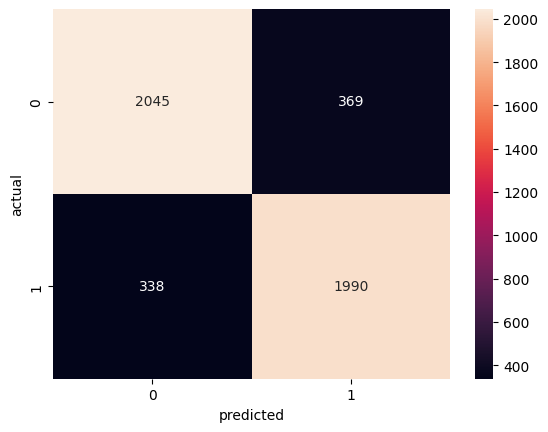

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('predicted')
plt.ylabel('actual')
plt.show()

In [ ]:
text=['This movie was fantastic and inspiring']
clean=preprocess(text[0])
vector=vectorizer.transform([clean])
prediction =model.predict(vector)
print("preducted sentiment:",prediction[0])

preducted sentiment: positive


In [ ]:
text=['This movie was good but the plot was diappointing']
clean=preprocess(text[0])
vector=vectorizer.transform([clean])
prediction =model.predict(vector)
print("preducted sentiment:",prediction[0])

preducted sentiment: negative


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
models = {
     "Naive bayes": MultinomialNB(),
     "Logistic Regression": LogisticRegression(),
     "Support Vector Machine": SVC(),
     "Random Forest": RandomForestClassifier(),
     "Gradient Boosting": GradientBoostingClassifier()

}

In [ ]:
results=[]
for name,model in models.items():
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  f1=f1_score(y_test,y_pred,pos_label='positive')
  results.append([name,accuracy,f1])

In [ ]:
results_df =pd.DataFrame(results,columns=['Model','Accuracy','F1 Score'])
results_df

,Model,Accuracy,F1 Score
0,Naive bayes,0.850907,0.849157
1,Logistic Regression,0.873893,0.873466
2,Support Vector Machine,0.878532,0.878430
3,Random Forest,0.835091,0.829778
4,Gradient Boosting,0.796921,0.802704


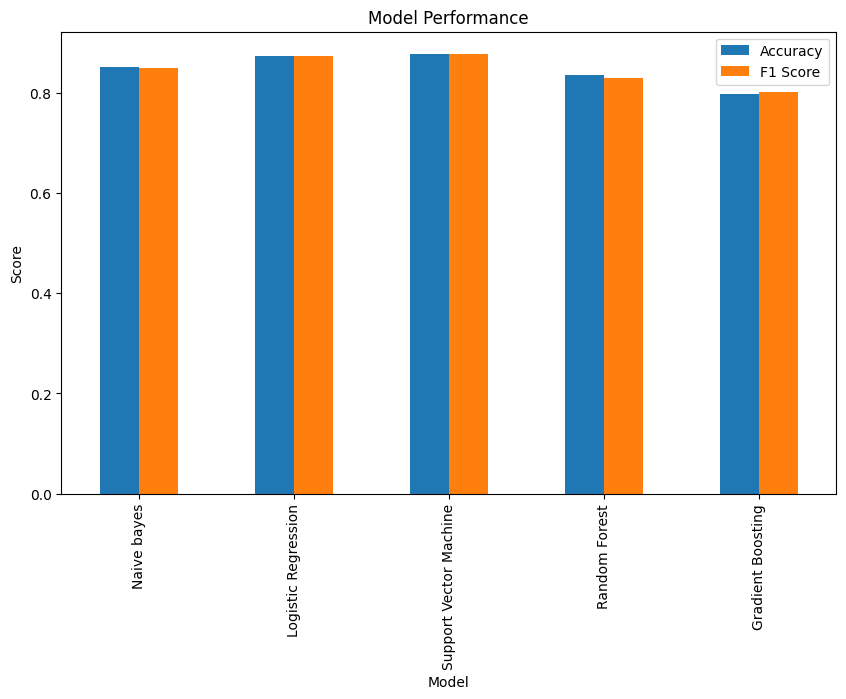

In [ ]:
results_df.set_index("Model")[["Accuracy","F1 Score"]].plot(kind="bar",figsize=(10,6))
plt.title("Model Performance")
plt.xlabel("Model")
plt.ylabel("Score")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the Logistic Regression model
log_reg_model = LogisticRegression(solver='liblinear', random_state=42)

# Define the parameter grid to search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Initialize GridSearchCV
# 'accuracy' is a common scoring metric for classification tasks
grid_search = GridSearchCV(log_reg_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation accuracy: ", grid_search.best_score_)

Best parameters found:  {'C': 1}
Best cross-validation accuracy:  0.8781627949607808


In [ ]:
# Get the best model from the grid search
best_log_reg_model = grid_search.best_estimator_

# Make predictions with the tuned model
y_pred_tuned = best_log_reg_model.predict(X_test)

# Evaluate the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned, pos_label='positive')

print(f"Tuned Logistic Regression Accuracy: {accuracy_tuned:.4f}")
print(f"Tuned Logistic Regression F1 Score: {f1_tuned:.4f}")
print("\nClassification Report for Tuned Logistic Regression:\n")
print(classification_report(y_test, y_pred_tuned))

Tuned Logistic Regression Accuracy: 0.8737
Tuned Logistic Regression F1 Score: 0.8732

Classification Report for Tuned Logistic Regression:

              precision    recall  f1-score   support

    negative       0.89      0.86      0.87      2414
    positive       0.86      0.89      0.87      2328

    accuracy                           0.87      4742
   macro avg       0.87      0.87      0.87      4742
weighted avg       0.87      0.87      0.87      4742



In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Define the Support Vector Machine model
svc_model = SVC(random_state=42)

# Define the parameter grid to search for SVC
param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf']
}

# Initialize GridSearchCV for SVC
grid_search_svc = GridSearchCV(svc_model, param_grid_svc, cv=3, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_svc.fit(X_train, y_train)

print("Best parameters found for SVC: ", grid_search_svc.best_params_)
print("Best cross-validation accuracy for SVC: ", grid_search_svc.best_score_)

In [ ]:
# Get the best SVC model from the grid search
best_svc_model = grid_search_svc.best_estimator_

# Make predictions with the tuned SVC model
y_pred_tuned_svc = best_svc_model.predict(X_test)

# Evaluate the tuned SVC model
accuracy_tuned_svc = accuracy_score(y_test, y_pred_tuned_svc)
f1_tuned_svc = f1_score(y_test, y_pred_tuned_svc, pos_label='positive')

print(f"Tuned Support Vector Machine Accuracy: {accuracy_tuned_svc:.4f}")
print(f"Tuned Support Vector Machine F1 Score: {f1_tuned_svc:.4f}")
print("\nClassification Report for Tuned Support Vector Machine:\n")
print(classification_report(y_test, y_pred_tuned_svc))